In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es




Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [3]:
  # Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig

In [6]:
# Load glasser atlas
# roi
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L_1 = f'{atlas_dir}/HumanLobes.L.label.gii'
model_name_R = f'{atlas_dir}/HumanLobes.R.label.gii'
lobes_atlas = atlas.read_data([model_name_L_1,model_name_R])

# Load glasser atlas
# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])



In [7]:
# define PFC parcel and get the indices of the PFC parcels
PFC_parcels = ['LOBE.FRONTAL']    # PNAS paper

# Load the GIFTI file
gifti_data = nb.load(model_name_L_1)
parcel_names = [label.label for label in gifti_data.labeltable.labels]
parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]
print(parcel_names)

# Get the indices of the PFC parcels
ROI_cortex = []
for name in PFC_parcels:
    ROI_cortex.append(parcel_names.index(name))


['???', 'LOBE.FRONTAL', 'LOBE.PARIETAL', 'LOBE.LIMBIC', 'LOBE.TEMPORAL', 'LOBE.OCCIPITAL', 'MEDIAL.WALL']


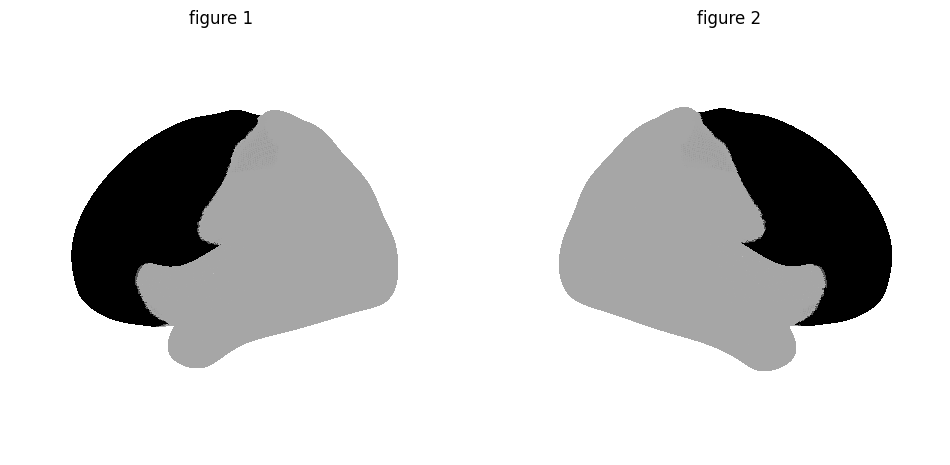

19107

In [8]:
# make mask for PFC and plot 
ROI_mask = np.isin(lobes_atlas, ROI_cortex).astype(int)
mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()

# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [9]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [10]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)
print(data_mdtb_s1_all.shape)

(24, 464, 59518)
(24, 29, 59518)


# Define mask used for top parcel identification, Glibrary estimation and evaluation of predicition error

# Get crossvalidated second moment matrix (GLib)

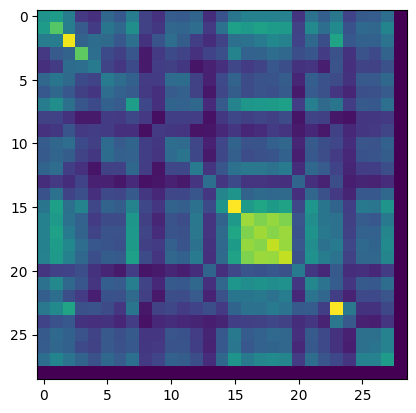

In [11]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

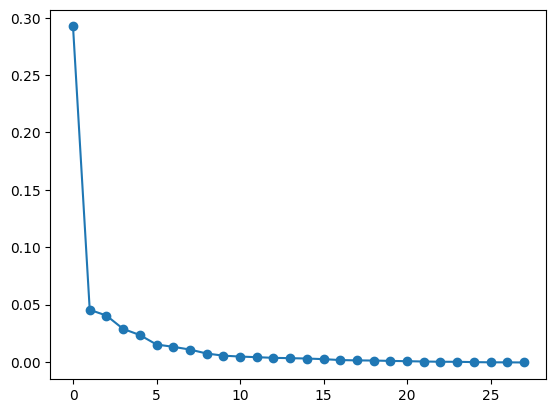

In [38]:
G_Lib_norest = G_Lib[:-1, :-1]
l_pfc, _ = np.linalg.eigh(G_Lib_norest)
l_pfc_sorted = np.sort(l_pfc)[::-1]
plt.plot(l_pfc_sorted, 'o-')

In [39]:
l_pfc_sorted

array([ 2.92364375e-01,  4.55481530e-02,  4.05128964e-02,  2.88984461e-02,
        2.35591815e-02,  1.52846298e-02,  1.32913203e-02,  1.08895915e-02,
        7.45681782e-03,  5.57451821e-03,  4.79625583e-03,  4.24767420e-03,
        3.68450470e-03,  3.38511973e-03,  3.08320843e-03,  2.54088639e-03,
        1.73669144e-03,  1.45305091e-03,  1.31579524e-03,  1.01267383e-03,
        7.53924598e-04,  4.82952889e-04,  2.65796717e-04,  2.20517916e-04,
       -4.07095700e-05, -2.30632154e-04, -2.47352531e-04, -3.64655753e-04])

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [12]:
# make data pt tensor
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_mdtb_s2_all = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
data_mdtb_s1_run = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)

ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)
parcelation = pt.tensor(glasser_atlas, dtype=pt.float32, device=device)

In [13]:
full_vs_train = es.get_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI=ROI_mask,parcel_list = None)
largest_parcels = es.get_largest_parcels(data_mdtb_s1_all,full_vs_train,ROI_mask = ROI_mask)
full_vs_test = es.get_Vs(data_mdtb_s2_all,parcellation=parcelation,ROI=ROI_mask,parcel_list = None)
num_parcels = len(largest_parcels)
print(num_parcels)

73


In [14]:
condition_df= ut.get_condition_indices(info_mdtb_1_run)

In [15]:
battery_sizes = [3,4,5,6,7,8,10,12,14,16]
parcel_sizes = [2,4,6,8,10,16,32]

parcel_sizes = [10]
battery_sizes = [6]

In [16]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    parcel_indices = largest_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")

        # Generate possible battery combinations for current battery size and evaluate each battery
        D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=n_task,seed=1,replacement=False)
        D = D.reset_index(drop=True)
        D = ut.build_combination_regressors(D,condition_df=condition_df,localizer_time=8)

        D_ev = ev.real_evaluate_dataframe_multiregion(D,
                                         YLib = data_mdtb_s1_run,VLib = VLib,
                                         ytest =data_mdtb_s2_all, vtest = vtest,
                                         indices = ROI_indices)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    
    


Processing parcel size: 10
Processing battery size: 6
Processing combination: 0


In [17]:
# find the row with the minimum cos_mean
min_cos_mean = results_df['cos_mean'].min()
min_cos_mean_row = results_df[results_df['cos_mean'] == min_cos_mean]

# get combination
combination = min_cos_mean_row['combination'].values[0]

# make tuple to list
combination = list(combination)

battery = ut.translate_battery(info_mdtb_1_all,combination)
print(min_cos_mean)
print(combination)
print(battery)
min_cos_mean_row

0.7799805402755737
[7, 8, 15, 18, 23, 28]
['Math' 'DigitJudgement' 'FingerSeq' 'Object0Back' 'VerbGen' 'rest']


,variance,variance_mc,inverse_trace,inverse_trace_mc,log_det,log_det_mc,num_eigenvalues,offdiag_sum,combination,n_unique,regressor_list,cos_subjects,cos_mean,n_parcel,n_task
553,0.12138,0.052347,-879.280484,-1.000000e+12,-22.054381,-45.823581,5,0.223787,"(7, 8, 15, 18, 23, 28)",7,"[[94, 384, 210, 65, 181], [95, 385, 211, 66, 1...","[0.8011865019798279, 0.7780178785324097, 0.870...",0.779981,10,6


In [ ]:
def build_combinations(G_lib, strategy='random',n_iter=1000,n_tasks=4,seed=1,replacement=True): 
    """ Builds a set of task-batteries and evalates them 
    G_lib: second moment matrices of task-library
    strategy: 'random' or 'exhaustive'
    n_iter: number of iterations for random strategy
    """
    np.random.seed(seed)
    D_list = []
    n_lib_task = G_lib.shape[0] - 1 # number of tasks excluding rest since its always added
    rest_idx_tuple=(28,)

    comb = []
    if strategy == 'random':
        for _ in range(n_iter):
            if _ % 1000 == 0:
                print(f'eval: {_}/{n_iter}')
            candidate = tuple(sorted(np.random.choice(n_lib_task, size=n_tasks-1, replace=replacement)))
            candidate = candidate + rest_idx_tuple
            comb.append(candidate)
        comb = list(set(comb))   
    else:
        raise ValueError('Invalid strategy')
        
    for i in range(len(comb)):
        # print progress
        if i % 1000 == 0:
            print(f'eval: {i}/{len(comb)}')
        n_unique = len(set(comb[i])) + 1
        d = ut.eigenval_crit(G_lib[comb[i],:][:,comb[i]],center=True)
        d['combination'] = [comb[i]]
        d['n_unique'] = [n_unique]
        D_list.append(pd.DataFrame(d))
    D = pd.concat(D_list)
    return D 
D_test = build_combinations(G_Lib, strategy='random',n_iter=1000000,n_tasks=6,seed=1,replacement=False)


eval: 0/1000000
eval: 1000/1000000
eval: 2000/1000000
eval: 3000/1000000
eval: 4000/1000000
eval: 5000/1000000
eval: 6000/1000000
eval: 7000/1000000
eval: 8000/1000000
eval: 9000/1000000
eval: 10000/1000000
eval: 11000/1000000
eval: 12000/1000000
eval: 13000/1000000
eval: 14000/1000000
eval: 15000/1000000
eval: 16000/1000000
eval: 17000/1000000
eval: 18000/1000000
eval: 19000/1000000
eval: 20000/1000000
eval: 21000/1000000
eval: 22000/1000000
eval: 23000/1000000
eval: 24000/1000000
eval: 25000/1000000
eval: 26000/1000000
eval: 27000/1000000
eval: 28000/1000000
eval: 29000/1000000
eval: 30000/1000000
eval: 31000/1000000
eval: 32000/1000000
eval: 33000/1000000
eval: 34000/1000000
eval: 35000/1000000
eval: 36000/1000000
eval: 37000/1000000
eval: 38000/1000000
eval: 39000/1000000
eval: 40000/1000000
eval: 41000/1000000
eval: 42000/1000000
eval: 43000/1000000
eval: 44000/1000000
eval: 45000/1000000
eval: 46000/1000000
eval: 47000/1000000
eval: 48000/1000000
eval: 49000/1000000
eval: 50000/1

In [26]:
D_test = D_test.reset_index(drop=True)
D_test = ut.build_combination_regressors(D_test,condition_df=condition_df,localizer_time=8)
D_test = ev.real_evaluate_dataframe_multiregion(D_test,
                                     YLib = data_mdtb_s1_run,VLib = VLib,
                                     ytest =data_mdtb_s2_all, vtest = vtest,
                                     indices = ROI_indices)

Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing combination: 10000
Processing combination: 11000
Processing combination: 12000
Processing combination: 13000
Processing combination: 14000
Processing combination: 15000
Processing combination: 16000
Processing combination: 17000
Processing combination: 18000
Processing combination: 19000
Processing combination: 20000
Processing combination: 21000
Processing combination: 22000
Processing combination: 23000
Processing combination: 24000
Processing combination: 25000
Processing combination: 26000
Processing combination: 27000
Processing combination: 28000
Processing combination: 29000
Processing combination: 30000
Processing combination: 31000
Processing combination: 32000
Processing combination:

In [27]:
# get the row combination with the highest 'variance' value
max_var = D_test['variance'].max()
max_var_row = D_test[D_test['variance'] == max_var]
print(max_var_row)

# same for log_det_mc
max_log_det_mc = D_test['offdiag_sum'].min()
max_log_det_mc_row = D_test[D_test['offdiag_sum'] == max_log_det_mc]
print(max_log_det_mc_row)


       variance  variance_mc  inverse_trace  inverse_trace_mc    log_det  \
50228  0.160275     0.062152    -675.591912     -1.000000e+12 -20.454697   

       log_det_mc  num_eigenvalues  offdiag_sum              combination  \
50228  -45.743188                5      0.33034  (2, 15, 18, 19, 23, 28)   

       n_unique                                     regressor_list  \
50228         7  [[89, 379], [102, 392, 218, 73, 189], [105, 39...   

                                            cos_subjects  cos_mean  
50228  [0.8056382536888123, 0.7773547768592834, 0.861...  0.773911  
      variance  variance_mc  inverse_trace  inverse_trace_mc    log_det  \
3815  0.043739       0.0236    -1354.39708     -1.000000e+12 -25.660319   

      log_det_mc  num_eigenvalues  offdiag_sum             combination  \
3815  -49.070955                5     0.056957  (8, 9, 13, 22, 24, 28)   

      n_unique                                     regressor_list  \
3815         7  [[95, 385, 211, 66, 182], [96,

In [37]:
# print the row with the second lowest cos_mean
D_test_sorted = D_test.sort_values(by='cos_mean')
D_test_sorted.iloc[4]


variance                                                     0.148226
variance_mc                                                   0.06126
inverse_trace                                              -395.83051
inverse_trace_mc                                -1000000000355.314209
log_det                                                    -19.911585
log_det_mc                                                 -44.952037
num_eigenvalues                                                     5
offdiag_sum                                                  0.286605
combination                                   (2, 15, 18, 23, 27, 28)
n_unique                                                            7
regressor_list      [[89, 379], [102, 392, 218, 73, 189], [105, 39...
cos_subjects        [0.8045142292976379, 0.7885444760322571, 0.871...
cos_mean                                                     0.774318
Name: 26648, dtype: object

In [30]:
combination = (2, 15, 18, 19, 23, 28)
print(ut.translate_battery(info_mdtb_1_all,list(combination)))
df = pd.DataFrame()
df['combination'] = [combination]
df = ut.build_combination_regressors(df,condition_df=condition_df,localizer_time=8)

YLib = data_mdtb_s1_run
VLib = full_vs_train[:,largest_parcels[:10]]
VLib = ev.center_matrix(VLib,axis=0)
VLib = ev.normalize_matrix(VLib,axis=0)

vtest = full_vs_test[:,largest_parcels[:10]]
vtest = ev.center_matrix(vtest,axis=0)
vtest = ev.normalize_matrix(vtest,axis=0)

ytest = data_mdtb_s2_all
ytest = ev.center_matrix(ytest,axis=1)
ytest = ev.normalize_matrix(ytest,axis=1)


li,mean = ev.real_evaluate_combination_multiregion(combination,df['regressor_list'][0],YLib,VLib,ytest,vtest,ROI_indices)
print(li)
print(mean)

['ToM' 'FingerSeq' 'Object0Back' 'Object2Back' 'VerbGen' 'rest']
tensor([0.8056, 0.7774, 0.8619, 0.6592, 0.7453, 0.7039, 0.7192, 0.7410, 0.9202,
        0.7267, 0.7069, 0.7891, 0.7545, 0.7324, 0.8402, 0.7501, 0.7907, 0.7290,
        0.8095, 0.7515, 0.8014, 0.8478, 0.7582, 0.8523], device='cuda:0')
tensor(0.7739, device='cuda:0')


In [25]:
combination = (8, 9, 13, 22, 24, 28)
df = pd.DataFrame()
df['combination'] = [combination]
df = ut.build_combination_regressors(df,condition_df=condition_df,localizer_time=8)

YLib = data_mdtb_s1_run
VLib = full_vs_train[:,largest_parcels[:10]]
VLib = ev.center_matrix(VLib,axis=0)
VLib = ev.normalize_matrix(VLib,axis=0)

vtest = full_vs_test[:,largest_parcels[:10]]
vtest = ev.center_matrix(vtest,axis=0)
vtest = ev.normalize_matrix(vtest,axis=0)

ytest = data_mdtb_s2_all
ytest = ev.center_matrix(ytest,axis=1)
ytest = ev.normalize_matrix(ytest,axis=1)


li,mean = ev.real_evaluate_combination_multiregion(combination,df['regressor_list'][0],YLib,VLib,ytest,vtest,ROI_indices)
print(li)
print(mean)

tensor([0.9155, 0.8847, 0.9603, 0.8241, 0.8484, 0.8668, 0.7968, 0.9188, 0.9665,
        0.8757, 0.8119, 0.8943, 0.8676, 0.8512, 0.9590, 0.8478, 0.9150, 0.8465,
        1.0296, 0.8565, 0.9217, 0.9575, 0.8622, 0.9148], device='cuda:0')
tensor(0.8914, device='cuda:0')


In [ ]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cortex-PFC_MDTB_ses-01_ses-02_results.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

In [ ]:
n_proposal_sets = 100
metrics = ["variance" , "log_det"] # Metrics to evaluate


# Get unique values of n_parcel and n_task from the results dataframe
unique_n_parcel = results_df["n_parcel"].unique()
unique_n_task = results_df["n_task"].unique()



In [ ]:
proposals_list = []
for n_parcel in unique_n_parcel:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in unique_n_task:
        print(f"Processing battery size: {n_task}")
        subset_df = results_df[(results_df["n_parcel"] == n_parcel) & (results_df["n_task"] == n_task)]
        
        for iter in range(n_proposal_sets):
            sampled_df = subset_df.sample(len(subset_df), replace=True)
            
            for metric in metrics:
                best_row = sampled_df.loc[sampled_df[metric].idxmax()]
                # if the same top battery is proposed multiple times, only keep the first instance
                if isinstance(best_row, pd.DataFrame):
                    best_row = best_row.iloc[0]
                
                cos_subjects = best_row["cos_subjects"]
                proposals_list.append({
                    "n_iter": iter,
                    "n_parcel": n_parcel,
                    "n_task": n_task,
                    "metric": metric,
                    "cos_subjects": cos_subjects,
                })


iter_df = pd.DataFrame(proposals_list)

Processing parcel size: 4
Processing battery size: 7
Processing parcel size: 10
Processing battery size: 7


# seperate the list of prediction errors of all subjects into values for each subject for the top battery by each metric in each iteration for each n_tasks and n_parcels

after seperating

In [ ]:
expanded_results = []
for _, row in iter_df.iterrows():
    if isinstance(row["cos_subjects"], str):
        row["cos_subjects"] = eval(row["cos_subjects"])
    row_cos_values = row["cos_subjects"]
    for i,subj_cos in enumerate(row_cos_values):
        cos_value = row_cos_values[i]
        expanded_results.append({
            "n_iter": row["n_iter"],
            "n_parcel": row["n_parcel"],
            "n_task": row["n_task"],
            "metric": row["metric"],
            "subject": i+1,
            "cos_value": cos_value
        })
# this is just expanded version of the iter_df
expanded_results_df = pd.DataFrame(expanded_results)

# this averages the results for each subject across all iterations
averaged_results_df = (
    expanded_results_df
    .groupby(["n_parcel", "n_task", "metric", "subject"], as_index=False)
    .agg({"cos_value": "mean"})
)

# Aggregate across subjects to get mean and SEM
aggregated_results_df = averaged_results_df.groupby(["n_parcel", "n_task", "metric"], as_index=False).agg(
    cos_mean=("cos_value", "mean"),
    cos_sem=("cos_value", lambda x: x.std() / np.sqrt(len(x)))  # SEM
)

# make a df for the baseline battery

In [ ]:
baseline_df = results_df.copy()
if isinstance(baseline_df["cos_subjects"].iloc[0], str):
    baseline_df["cos_subjects"] = baseline_df["cos_subjects"].apply(eval)
baseline_df = baseline_df.explode("cos_subjects")  
baseline_df["cos_subjects"] = baseline_df["cos_subjects"].astype(float)

baseline_aggregated_df = baseline_df.groupby(["n_parcel", "n_task"], as_index=False).agg(
    cos_mean=("cos_subjects", "mean")
)

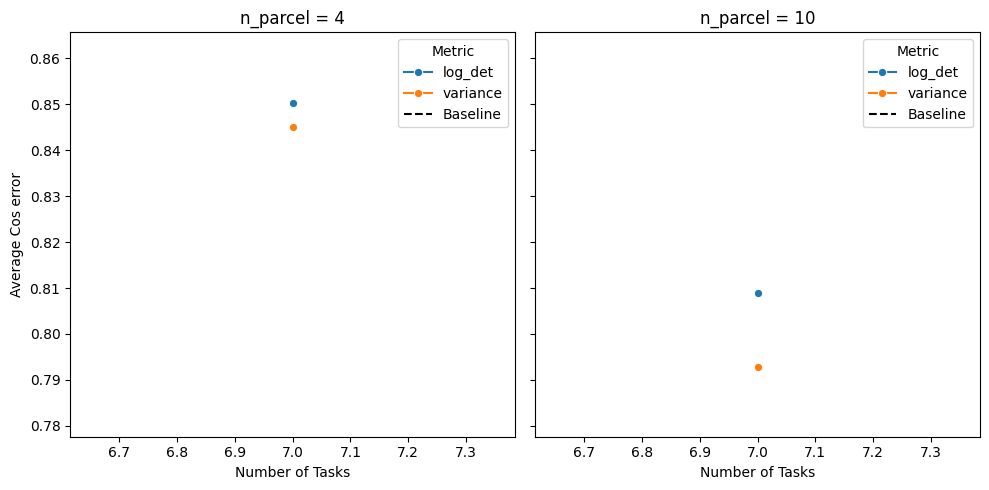

In [ ]:
num_plots = len(unique_n_parcel)
n_cols = int(np.ceil(np.sqrt(num_plots))) 
n_rows = int(np.ceil(num_plots / n_cols)) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharex=False, sharey=True)
axes = np.array(axes).flatten()

for ax, n_parcel in zip(axes, unique_n_parcel):
    df_plot = aggregated_results_df[aggregated_results_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=df_plot, x="n_task", y="cos_mean", hue="metric", ax=ax, marker="o"
    )

    for metric in df_plot["metric"].unique():
        metric_data = df_plot[df_plot["metric"] == metric]
        ax.fill_between(metric_data["n_task"],
                        metric_data["cos_mean"] - metric_data["cos_sem"],
                        metric_data["cos_mean"] + metric_data["cos_sem"],
                        alpha=0.2)

    # Plot the baseline for this n_parcel
    baseline_data = baseline_aggregated_df[baseline_aggregated_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=baseline_data, x="n_task", y="cos_mean", ax=ax, color="black", linestyle="dashed", label="Baseline"
    )
    ax.set_title(f"n_parcel = {n_parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Average Cos error")
    ax.legend(title="Metric")

# Hide unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()



In [ ]:
combination = (4,15,16,21,1,24)
df = pd.DataFrame()
df['combination'] = [combination]
df = ut.build_combination_regressors(df,condition_df=condition_df,localizer_time=8)

YLib = data_mdtb_s1_run
VLib = full_vs_train[:,largest_parcels[:6]]
VLib = ev.center_matrix(VLib,axis=0)
VLib = ev.normalize_matrix(VLib,axis=0)

vtest = full_vs_test[:,largest_parcels[:6]]
vtest = ev.center_matrix(vtest,axis=0)
vtest = ev.normalize_matrix(vtest,axis=0)

ytest = data_mdtb_s2_all
ytest = ev.center_matrix(ytest,axis=0)
ytest = ev.normalize_matrix(ytest,axis=0)

Modified_indices = np.arange(data_mdtb_s1_all.shape[2])
print(Modified_indices)
li,mean = ev.real_evaluate_combination_multiregion(combination,df['regressor_list'][0],YLib,VLib,ytest,vtest,ROI_indices)
print(li)
print(mean)

[    0     1     2 ... 59515 59516 59517]
tensor([0.9717, 1.1012, 1.0585, 0.9925, 0.9017, 0.9585, 1.0029, 0.9942, 0.9942,
        1.0202, 0.9869, 0.8725, 0.9305, 1.0958, 1.0473, 1.0352, 0.9332, 0.8783,
        0.9823, 1.0070, 1.0813, 1.1019, 1.0241, 1.0284], device='cuda:0')
tensor(1., device='cuda:0')
